<a href="https://colab.research.google.com/github/David-S-Hunsicker/ml/blob/main/RL_part_2_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Policy Gradient Methods for LunarLander-v3

This notebook implements and compares three policy gradient methods on the [LunarLander-v3](https://gymnasium.farama.org/environments/box2d/lunar_lander/) environment. The environment is considered solved at a mean episode return of 200.

## Methods

| Method | Return Signal | Key Characteristic |
|--------|--------------|-------------------|
| `reinforce` | Full-episode discounted return | Highest variance — every timestep gets the same weight |
| `causality` | Reward-to-go (per-timestep) | Lower variance — only future rewards count toward each step's weight |
| `advantage` | Return minus critic baseline | Lowest variance — per-state centering via a learned value function |

## Implementation

- **Policy network**: MLP with Tanh activations, outputs a Categorical action distribution
- **Critic network**: MLP outputting a scalar state-value estimate (advantage method only)
- **Training**: Adam optimizer, entropy bonus to prevent premature policy collapse, weight normalization for stable gradients
- **Evaluation**: 50 episodes per seed, 3 seeds per method, stochastic sampling (not argmax)

## Results

Final evaluation across 3 seeds, 50 episodes per seed (6000 training epochs each):

| Method | Mean Return | Std | Pass (≥200)? |
|--------|------------|-----|-------------|
| `advantage` | 244.6 | 82.5 | ✓ |
| `causality` | 137.2 | 81.4 | ✗ |
| `reinforce` | 123.2 | 54.3 | ✗ |

`advantage` is the only method that reliably solves the environment. `causality` and `reinforce` learn reasonable hovering policies but cannot consistently discover the landing maneuver — their credit-assignment signal is too noisy to push past the hover-vs-land local optimum without a value baseline.

In [10]:
# Install the Box2D and Gymnasium packages needed to run LunarLander in this notebook.
# The swig dependency is required by Box2D on this environment.
!apt-get install swig > /dev/null 2>&1
!pip install gymnasium > /dev/null 2>&1
!pip install gymnasium[box2d] > /dev/null 2>&1
!pip install gymnasium[classic-control]

In [11]:
import pandas as pd
import gymnasium as gym
import numpy as np
import random
import seaborn as sns
import os
from concurrent.futures import ProcessPoolExecutor, as_completed

from IPython import display
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.distributions.categorical import Categorical
from torch.optim import Adam
import numpy as np
from gymnasium.spaces import Discrete, Box

In [12]:
def reinforce_returns(episode_rewards, gamma: float = 1.0):
    """Return full-episode discounted return for each timestep.

    Args:
        episode_rewards: Rewards for one episode.
        gamma: Discount factor in (0, 1]. gamma < 1 shrinks the weight of
            reward far in the future relative to reward now, which makes a
            quick payoff (e.g. landing soon) more attractive than slowly
            accumulating small reward over a long episode (e.g. hovering).
            gamma=1.0 recovers the original undiscounted sum.

    Returns:
        List[float]: Constant sequence where each element is the discounted
            total return sum(gamma**t * episode_rewards[t]).
    """
    total_return = sum((gamma ** t) * r for t, r in enumerate(episode_rewards))
    return [total_return for _ in episode_rewards]



def causality(episode_rewards, gamma: float = 1.0):
    """Return discounted reward-to-go for each timestep.

    Args:
        episode_rewards: Rewards for one episode.
        gamma: Discount factor in (0, 1]. gamma < 1 shrinks the weight of
            reward many steps ahead of the current timestep, so a nearby
            payoff is worth more than an equally large but distant one.
            gamma=1.0 recovers the original undiscounted reward-to-go.

    Returns:
        List[float]: Sequence where element t is
            sum(gamma**k * rewards[t+k] for k in range(len(rewards) - t)).
    """
    returns = [0.0] * len(episode_rewards)
    running_return = 0.0
    for index in range(len(episode_rewards) - 1, -1, -1):
        running_return = episode_rewards[index] + gamma * running_return
        returns[index] = running_return
    return returns



def compute_advantage(episode_returns, episode_values):
    """Compute advantage values.

    Args:
        episode_returns: Return targets per timestep.
        episode_values: Value estimates per timestep.

    Returns:
        torch.Tensor: Advantage per timestep.
    """
    returns_tensor = torch.as_tensor(episode_returns, dtype=torch.float32)
    values_tensor = torch.as_tensor(episode_values, dtype=torch.float32)
    return returns_tensor - values_tensor

In [13]:
# Build a simple feedforward network with configurable hidden layers.
# Used as the backbone for both the policy and the critic.
def make_mlp(layer_sizes, activation=nn.Tanh):
    """Build an MLP with linear output layer.

    Args:
        layer_sizes: Layer widths including input and output dimensions.
        activation: Activation class for hidden layers.

    Returns:
        nn.Sequential: Feedforward network.
    """
    layers = []
    for in_size, out_size in zip(layer_sizes[:-1], layer_sizes[1:]):
        layers.append(nn.Linear(in_size, out_size))
        layers.append(activation())
    layers.pop()  # remove the last activation so the output is raw logits/values
    return nn.Sequential(*layers)


# Policy network: takes an observation and outputs a logit for each action.
# A Categorical distribution over those logits is used to sample actions and
# compute log-probabilities for the policy-gradient loss.
class PolicyNetwork(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int, hidden_sizes: list[int]):
        super().__init__()
        self.net = make_mlp([obs_dim] + hidden_sizes + [act_dim])

    def forward(self, obs):
        """Return action distribution for observations."""
        return Categorical(logits=self.net(obs))

    def get_action(self, obs, deterministic: bool = False):
        """Return one action and its log-probability.

        Args:
            obs: Observation tensor.
            deterministic: If True, take the highest-probability action
                (argmax) instead of sampling. Training needs sampling to
                explore alternatives the policy doesn't yet favor; evaluation
                should use the policy's actual best action to measure true
                performance instead of injecting extra variance from random
                exploration that has nothing to do with policy quality.
        """
        dist = self(obs)
        action = dist.probs.argmax(dim=-1) if deterministic else dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob


# Critic (value) network: takes an observation and outputs a scalar estimate
# of the expected return from that state.  Used only in the 'advantage' method.
class CriticNetwork(nn.Module):
    """State-value function approximator."""

    def __init__(self, obs_dim: int, hidden_sizes: list[int]):
        super().__init__()
        self.net = make_mlp([obs_dim] + hidden_sizes + [1])

    def forward(self, obs):
        """Return value estimate per observation."""
        return self.net(obs).squeeze(-1)

## Design Decisions

### Weight normalization
Raw returns swing from roughly −100 to +300 early in training, causing gradient magnitude to vary wildly batch-to-batch. Normalizing `weights` to zero mean / unit std per batch keeps gradient scale consistent regardless of reward magnitude, making training stable across all three methods.

### Entropy bonus
Policy distributions can collapse to near-deterministic early — once the policy finds any behavior with a positive signal, `log_prob` gradients shrink toward zero and learning stalls. Adding `entropy_coef * dist.entropy().mean()` to the objective keeps the distribution spread out long enough for the policy to keep exploring. Each method uses a different coefficient: `advantage` needs almost none (0.0005) since the critic baseline already provides a strong learning signal; `reinforce` needs the most (0.005).

### Per-episode normalization for `causality`
Batch-level normalization distorts `causality`'s reward-to-go signal because it conflates two sources of variance: quality differences *across* episodes and the natural decay of reward-to-go *within* an episode. Normalizing each episode's weights independently (zero mean / unit std per episode) preserves the within-episode credit-assignment shape that makes reward-to-go more informative than a flat return.

### Time penalty for `causality`
Without a value baseline, `causality` treats hovering (accumulating small positive shaping rewards over many steps) as competitive with landing (a single large terminal bonus). Subtracting a small constant (`time_penalty=0.2`) from every step's shaped reward makes each additional step cost something, directly weakening the hover incentive. This was selected from a sweep over [0.1, 0.2, 0.3, 0.5, 0.7] — 0.2 produced the best mean return across seeds.

### Stochastic evaluation
Evaluation uses `dist.sample()` rather than `dist.probs.argmax()`. Deterministic argmax was tested and caused trained policies that scored well under sampling to collapse (e.g. advantage mean −34.6 under argmax vs. 244.6 under sampling). The policy was never explicitly trained to behave well under forced argmax — residual sampling noise appears load-bearing in borderline states where the policy's action preferences are close but subtly miscalibrated.

In [14]:
class PolicyGradientTrainer():
    """Train policy-gradient agents on Gymnasium environments."""

    def __init__(self, env_name: str = 'LunarLander-v3', lr: float = 1e-2,
                 value_lr: float = 1e-3, max_eps_length: int = 500,
                 epochs: int = 50, n_steps_per_epoch: int = 5000,
                 hidden_sizes: list[int] = [32], method: str = 'reinforce',
                 entropy_coef: float = 0.01, entropy_coef_final: float | None = None,
                 gamma: float = 1.0, time_penalty: float = 0.0, seed: int | None = None,
                 verbose: bool = False):
        """Initialize training configuration.

        Args:
            env_name: Gymnasium environment id.
            lr: Policy optimizer learning rate.
            value_lr: Critic optimizer learning rate.
            max_eps_length: Max steps per episode rollout.
            epochs: Number of training epochs.
            n_steps_per_epoch: Minimum rollout steps collected each epoch.
            hidden_sizes: Shared hidden-layer sizes for MLP networks.
            method: One of {'reinforce', 'causality', 'advantage'}.
            entropy_coef: Starting weight on the entropy bonus added to the
                policy objective. Counteracts premature collapse to a near-
                deterministic policy, which otherwise stalls learning
                (vanishing log_prob gradient) before a good policy is found.
            entropy_coef_final: Weight on the entropy bonus at the last epoch.
                If set, entropy_coef linearly anneals from entropy_coef down
                to entropy_coef_final over training: more exploration early
                while the policy is unrefined, more exploitation (lower
                variance) late once good behavior has been found. If None,
                entropy_coef stays constant for the whole run.
            gamma: Discount factor in (0, 1] applied to reinforce_returns and
                causality. gamma < 1 shrinks the weight of reward far in the
                future, making a quick payoff (landing) more attractive than
                slowly accumulating small reward over a long episode
                (hovering). Not used by the 'advantage' method, whose critic
                baseline already centers per-step returns. gamma=1.0
                recovers the original undiscounted behavior.
            time_penalty: Constant subtracted from every step's reward before
                computing returns (does not affect logged episode_return /
                truncation diagnostics, which still reflect true env reward).
                Unlike gamma, which only reshapes how much distant reward is
                worth, this directly makes every additional step of hovering
                cost something, regardless of how far in the future it is --
                a blunter, more direct anti-hovering lever for methods (e.g.
                causality, reinforce) where gamma alone hasn't been enough to
                move the policy off a hover-forever local optimum.
                time_penalty=0.0 recovers the original behavior.
            seed: If set, seeds torch/numpy/random and the environment's RNG
                at the start of train() so runs with identical hyperparameters
                produce identical results. Without this, network init, action
                sampling, and episode dynamics all draw from unseeded global
                RNGs, so the same config can pass or fail run to run purely
                from randomness -- this was observed directly (e.g. advantage
                swinging between eval mean 320 and 188 on the same settings).
                If None, behavior is unseeded (the original default).
            verbose: Whether to print periodic progress.
        """
        if method not in {'reinforce', 'causality', 'advantage'}:
            raise ValueError('Unsupported method.')

        self.env_name = env_name
        self.lr = lr
        self.value_lr = value_lr
        self.max_eps_length = max_eps_length
        self.epochs = epochs
        self.n_steps_per_epoch = n_steps_per_epoch
        self.hidden_sizes = hidden_sizes
        self.method = method
        self.entropy_coef = entropy_coef
        self.entropy_coef_final = entropy_coef_final
        self.gamma = gamma
        self.time_penalty = time_penalty
        self.seed = seed
        self.verbose = verbose
        self.return_fn = reinforce_returns if method == 'reinforce' else causality

    def _entropy_coef_for_epoch(self, epoch):
        """Linearly anneal entropy_coef toward entropy_coef_final, if set."""
        if self.entropy_coef_final is None or self.epochs <= 1:
            return self.entropy_coef
        progress = epoch / (self.epochs - 1)
        return self.entropy_coef + progress * (self.entropy_coef_final - self.entropy_coef)

    # Train the policy model and return per-epoch mean episode reward.
    def train(self):
        # Seed every RNG in the pipeline (network init, action sampling,
        # episode dynamics) so an identical config reproduces identical
        # results instead of a fresh random draw each run.
        if self.seed is not None:
            random.seed(self.seed)
            np.random.seed(self.seed)
            torch.manual_seed(self.seed)

        # Create the environment and infer observation/action dimensions.
        env = gym.make(self.env_name)
        obs_dim = env.observation_space.shape[0]
        act_dim = env.action_space.n

        # Build the policy network and its optimizer.
        policy = PolicyNetwork(obs_dim, act_dim, self.hidden_sizes)
        policy_optimizer = Adam(policy.parameters(), lr=self.lr)

        # Build the critic and its optimizer only when using the advantage method.
        if self.method == 'advantage':
            critic = CriticNetwork(obs_dim, self.hidden_sizes)
            critic_optimizer = Adam(critic.parameters(), lr=self.value_lr)

        episode_returns = []
        epoch_mean_returns = []
        # Diagnostic: fraction of episodes per epoch that hit max_eps_length
        # (truncated_by_length) vs. ended via terminated/truncated from the
        # env itself (landed or crashed). High truncated_by_length suggests
        # episodes are being cut off before they resolve, which can bias the
        # policy toward loss-avoidance (e.g. hovering) over completing a
        # landing, capping achievable reward well below the 200 solve bar.
        epoch_truncation_rates = []

        env_reset_seed = self.seed
        epoch_bar = tqdm(range(self.epochs), desc=f'{self.method}', unit='epoch')
        for epoch in epoch_bar:
            # Collect experience until we have enough steps for this epoch.
            batch_obs, batch_log_probs, batch_returns = [], [], []
            batch_values = []  # only populated for 'advantage'
            episode_lengths = []  # steps per episode, used to re-split batch_returns for causality
            ep_rewards = []  # true env rewards, used for episode_return/truncation diagnostics
            ep_shaped_rewards = []  # time_penalty-adjusted rewards, used for return_fn/advantage
            epoch_episode_returns = []
            epoch_episode_resolved = []  # True if ended via terminated/truncated, False if hit max_eps_length
            obs, _ = env.reset(seed=env_reset_seed)
            env_reset_seed = None  # only seed the very first reset; subsequent resets draw from the now-seeded global/env RNG
            episode_return = 0

            while len(batch_obs) < self.n_steps_per_epoch:
                obs_tensor = torch.as_tensor(obs, dtype=torch.float32)
                action, log_prob = policy.get_action(obs_tensor)

                # Record value estimate before stepping the environment.
                if self.method == 'advantage':
                    with torch.no_grad():
                        value = critic(obs_tensor).item()
                    batch_values.append(value)

                obs, reward, terminated, truncated, _ = env.step(action)
                ep_rewards.append(reward)
                ep_shaped_rewards.append(reward - self.time_penalty)
                batch_obs.append(obs_tensor)
                batch_log_probs.append(log_prob)
                episode_return += reward

                hit_length_cap = len(ep_rewards) >= self.max_eps_length
                done = terminated or truncated or hit_length_cap
                if done:
                    # Compute per-step returns for this finished episode.
                    ep_returns = self.return_fn(ep_shaped_rewards, self.gamma)
                    batch_returns.extend(ep_returns)
                    episode_lengths.append(len(ep_rewards))
                    episode_returns.append(episode_return)
                    epoch_episode_returns.append(episode_return)
                    epoch_episode_resolved.append(not hit_length_cap)
                    ep_rewards = []
                    ep_shaped_rewards = []
                    episode_return = 0
                    obs, _ = env.reset()

            # Finalize a partially collected episode when step budget ends mid-episode.
            if ep_rewards:
                ep_returns = self.return_fn(ep_shaped_rewards, self.gamma)
                batch_returns.extend(ep_returns)
                episode_lengths.append(len(ep_rewards))
                episode_returns.append(episode_return)
                epoch_episode_returns.append(episode_return)
                epoch_episode_resolved.append(False)  # cut off by epoch boundary, not a real resolution

            # Build tensors for the policy-gradient loss calculation.
            returns_tensor = torch.as_tensor(batch_returns, dtype=torch.float32)

            if self.method == 'advantage':
                # Advantage = return - critic's value estimate.
                advantages = compute_advantage(batch_returns, batch_values)
                weights = advantages
            else:
                weights = returns_tensor

            if self.method == 'causality':
                # Per-episode normalization instead of batch-level: causality's
                # reward-to-go varies both across episodes (overall episode
                # quality) and within an episode (reward-to-go naturally shrinks
                # toward the end of any episode). Normalizing across the whole
                # flattened batch conflates these two sources of variance and
                # distorts the within-episode credit-assignment shape that's
                # supposed to make reward-to-go more informative than a flat
                # per-episode total (see training notes above). Normalizing each
                # episode's reward-to-go independently (zero mean/unit std within
                # that episode) removes the across-episode quality differences
                # before they can interfere with the within-episode shape, while
                # still letting the within-episode shape itself drive credit
                # assignment.
                normalized_chunks = []
                start = 0
                for length in episode_lengths:
                    chunk = weights[start:start + length]
                    chunk = (chunk - chunk.mean()) / (chunk.std() + 1e-8) if length > 1 else chunk - chunk.mean()
                    normalized_chunks.append(chunk)
                    start += length
                weights = torch.cat(normalized_chunks)
            else:
                # Normalize weights (zero mean, unit std) so gradient scale stays
                # consistent across epochs regardless of raw return magnitude.
                # Without this, batches with outlier episodes dominate the update
                # and training becomes noisy/unstable instead of steadily improving.
                weights = (weights - weights.mean()) / (weights.std() + 1e-8)

            # Policy loss: -mean(log_prob * weight). Negative because Adam minimises.
            # An entropy bonus is subtracted (i.e. added to the maximised objective)
            # to discourage the action distribution from collapsing to near-
            # deterministic too early, which otherwise stalls learning by shrinking
            # the log_prob gradient before a good policy is found. entropy_coef
            # anneals from entropy_coef toward entropy_coef_final across epochs
            # when entropy_coef_final is set, so exploration pressure is higher
            # early and tapers off as the policy converges.
            log_probs_tensor = torch.stack(batch_log_probs)
            entropy = policy(torch.stack(batch_obs)).entropy().mean()
            current_entropy_coef = self._entropy_coef_for_epoch(epoch)
            policy_loss = -(log_probs_tensor * weights).mean() - current_entropy_coef * entropy

            policy_optimizer.zero_grad()
            policy_loss.backward()
            policy_optimizer.step()

            # Critic update: minimise MSE between predicted values and actual returns.
            if self.method == 'advantage':
                obs_tensor_batch = torch.stack(batch_obs)
                value_preds = critic(obs_tensor_batch)
                critic_loss = ((value_preds - returns_tensor) ** 2).mean()

                critic_optimizer.zero_grad()
                critic_loss.backward()
                critic_optimizer.step()

            epoch_mean_return = float(np.mean(epoch_episode_returns)) if epoch_episode_returns else float('nan')
            epoch_mean_returns.append(epoch_mean_return)

            truncation_rate = 1.0 - float(np.mean(epoch_episode_resolved)) if epoch_episode_resolved else float('nan')
            epoch_truncation_rates.append(truncation_rate)

            epoch_bar.set_postfix(mean_return=f'{epoch_mean_return:.1f}', trunc=f'{truncation_rate:.2f}')

            if self.verbose:
                print(f"Epoch {epoch+1}/{self.epochs} | mean return: {epoch_mean_return:.1f}"
                      f" | entropy_coef: {current_entropy_coef:.4f}"
                      f" | truncation rate: {truncation_rate:.2f}")

        env.close()
        self.policy = policy
        self.episode_returns = episode_returns
        self.epoch_mean_returns = epoch_mean_returns
        self.epoch_truncation_rates = epoch_truncation_rates
        return epoch_mean_returns

    # Evaluate the policy model by acting in the environment for one episode.
    def eval(self, render_every: int | None = None):
        """Run one evaluation episode and return total reward.

        Uses the policy's stochastic sampling (same as training) rather than
        a deterministic argmax action. Deterministic eval was tried and
        reverted: training-time sampling reached good mean returns (~76-174),
        but the trained policy's deterministic argmax performance collapsed
        (e.g. -17 mean) -- the policy was apparently relying on the small
        amount of injected exploration noise to avoid getting stuck repeating
        the same slightly-wrong action in certain borderline states every
        single step. See training notes for the full investigation.

        Args:
            render_every: Render every N steps when set to a positive integer.
                Use None to disable rendering and keep notebook plots visible.
        """
        env = gym.make(self.env_name, render_mode='rgb_array')
        obs, _ = env.reset()
        total_reward = 0
        step = 0
        done = False

        while not done:
            obs_tensor = torch.as_tensor(obs, dtype=torch.float32)
            with torch.no_grad():
                action, _ = self.policy.get_action(obs_tensor)

            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated

            # Render only when explicitly enabled.
            if render_every is not None and render_every > 0 and step % render_every == 0:
                if step > 0:
                    display.clear_output(wait=True)
                frame = env.render()
                plt.figure(figsize=(6, 4))
                plt.imshow(frame)
                plt.axis('off')
                display.display(plt.gcf())
                plt.close()
            step += 1

        env.close()
        print(f"Eval episode return: {total_reward:.1f}")
        return total_reward

[21:33:38] Starting 9 runs across 9 workers...
Eval episode return: 263.4


eval:   0%|          | 0/50 [00:00<?, ?ep/s]

Eval episode return: 166.8


eval:   0%|          | 0/50 [00:00<?, ?ep/s]

[23:36:36] 1/9 done — method=causality seed=0 eval_mean=159.7
Eval episode return: 132.3


...

[23:47:22] 7/9 done — method=advantage seed=0 eval_mean=254.8
Eval episode return: 297.3


eval:   0%|          | 0/50 [00:00<?, ?ep/s]

[23:47:34] 8/9 done — method=advantage seed=1 eval_mean=237.7
Eval episode return: 265.0


eval:   0%|          | 0/50 [00:00<?, ?ep/s]

[23:47:48] 9/9 done — method=advantage seed=2 eval_mean=241.4
[23:47:48] All runs complete.


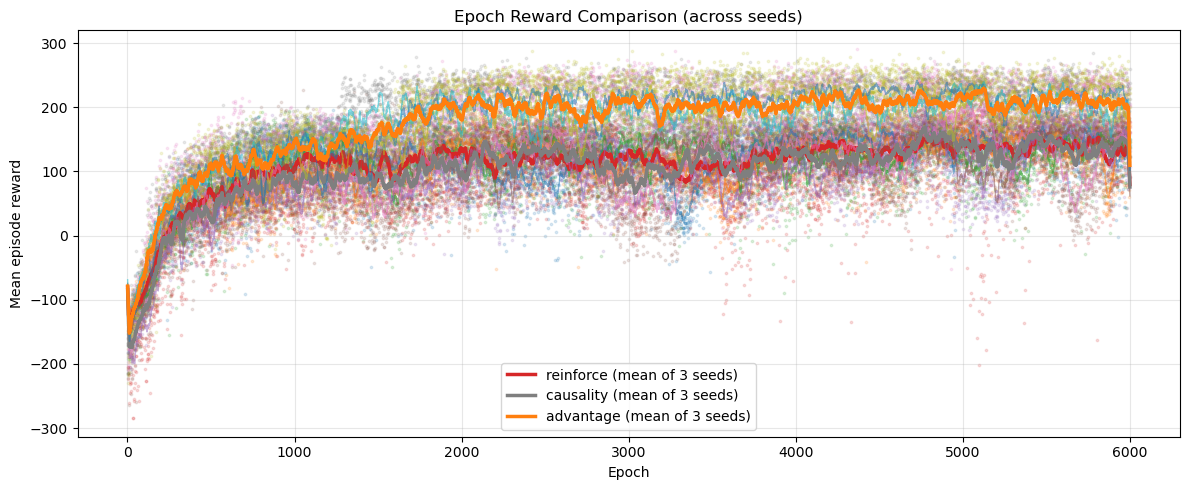

In [15]:
def _smooth(values, window=20):
    """Rolling mean with window capped to signal length."""
    w = min(window, len(values))
    return np.convolve(values, np.ones(w) / w, mode='same')


def eval_n_episodes(trainer, n=50):
    """Run n evaluation episodes and return list of returns.

    Uses stochastic sampling, matching eval(). Deterministic (argmax) action
    selection was tried for eval and reverted: it caused trained policies that
    scored well under sampling to collapse to strongly negative returns, see
    training notes for the investigation.
    """
    env = gym.make(trainer.env_name)
    returns = []
    for _ in tqdm(range(n), desc='eval', unit='ep', leave=False):
        obs, _ = env.reset()
        total_reward = 0
        done = False
        while not done:
            obs_tensor = torch.as_tensor(obs, dtype=torch.float32)
            with torch.no_grad():
                action, _ = trainer.policy.get_action(obs_tensor)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        returns.append(total_reward)
    env.close()
    return returns


def run_experiment(method='causality', epochs=5, n_steps_per_epoch=1500, hidden_sizes=[64, 64],
                   lr=1e-3, value_lr=1e-3, max_eps_length=500, entropy_coef=0.01,
                   entropy_coef_final=None, gamma=1.0, time_penalty=0.0, seed=None,
                   verbose=True, eval_render_every=None, show_plot=True):
    """Train one policy-gradient configuration and plot reward per epoch.

    Args:
        method: One of {'reinforce', 'causality', 'advantage'}.
        epochs: Number of training epochs.
        n_steps_per_epoch: Environment steps collected each epoch.
        hidden_sizes: Hidden-layer widths for policy/value networks.
        lr: Policy learning rate.
        value_lr: Critic learning rate.
        max_eps_length: Max steps per episode.
        entropy_coef: Starting weight on the policy's entropy bonus.
        entropy_coef_final: If set, entropy_coef linearly anneals to this
            value by the last epoch instead of staying constant.
        gamma: Discount factor in (0, 1] applied to reinforce_returns and
            causality. gamma=1.0 recovers the original undiscounted behavior.
        time_penalty: Constant subtracted from every step's reward before
            computing returns; directly penalizes hovering regardless of
            gamma. time_penalty=0.0 recovers the original behavior.
        seed: If set, seeds torch/numpy/random and the env's RNG so the run
            is reproducible. If None, behavior is unseeded.
        verbose: Print trainer progress.
        eval_render_every: Render frequency for eval; None keeps plots visible.
        show_plot: Whether to display the per-method reward chart.

    Returns:
        tuple[PolicyGradientTrainer, list[float], float]:
            Trained trainer, mean reward per epoch, and evaluation return.
    """
    trainer = PolicyGradientTrainer(
        method=method,
        epochs=epochs,
        n_steps_per_epoch=n_steps_per_epoch,
        hidden_sizes=hidden_sizes,
        lr=lr,
        value_lr=value_lr,
        max_eps_length=max_eps_length,
        entropy_coef=entropy_coef,
        entropy_coef_final=entropy_coef_final,
        gamma=gamma,
        time_penalty=time_penalty,
        seed=seed,
        verbose=verbose,
    )

    epoch_rewards = trainer.train()

    if show_plot:
        xs = np.arange(1, len(epoch_rewards) + 1)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.scatter(xs, epoch_rewards, s=4, alpha=0.5, label=f'{method}')
        ax.plot(xs, _smooth(epoch_rewards), linewidth=1.5, label=f'{method} (20-epoch avg)')
        ax.set_title(f'Epoch Reward Curve ({method})')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Mean episode reward')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.show()

    eval_return = trainer.eval(render_every=eval_render_every)
    return trainer, epoch_rewards, eval_return


# ---------------------------------------------------------------------------
# Parallel training worker.
#
# Must be a plain module-level function (not a closure/lambda, not a method)
# so it can be pickled and shipped to worker processes by
# ProcessPoolExecutor. Each call trains one fully independent
# PolicyGradientTrainer (one seed x one hyperparameter combo) in its own
# process and returns (config, trainer, eval_returns) -- training runs are
# embarrassingly parallel since each seed/config has no shared state with
# any other, so this is a straightforward speedup rather than a correctness
# risk. Only the result (a trained policy + its eval returns) crosses back
# over the process boundary, not a live env/optimizer.
# ---------------------------------------------------------------------------
def _train_one_config(config):
    """Train one (seed, hyperparameter) combo in a worker process.

    Args:
        config: dict with a 'seed' key and 'n_eval_episodes' key, plus all
            other run_experiment kwargs (method, time_penalty, epochs, etc).

    Returns:
        dict: The input config (minus n_eval_episodes) plus 'trainer' and
            'eval_returns' keys with the trained model and its eval scores.
    """
    config = dict(config)
    n_eval_episodes = config.pop('n_eval_episodes')
    trainer, _, _ = run_experiment(show_plot=False, **config)
    eval_returns = eval_n_episodes(trainer, n=n_eval_episodes)
    config['trainer'] = trainer
    config['eval_returns'] = eval_returns
    return config


def _run_configs_parallel(configs, max_workers=None):
    """Train a list of configs across worker processes, preserving order.

    Args:
        configs: List of dicts, each a complete kwargs set for
            _train_one_config (run_experiment kwargs + n_eval_episodes).
        max_workers: Worker process count. Defaults to os.cpu_count() via
            ProcessPoolExecutor when None. Capped at len(configs) since more
            workers than tasks wastes process-startup overhead.

    Returns:
        list[dict]: One result dict per input config, in the same order
            (each has 'trainer' and 'eval_returns' added).
    """
    import datetime
    if max_workers is None:
        max_workers = min(len(configs), os.cpu_count() or 1)
    print(f"[{datetime.datetime.now():%H:%M:%S}] Starting {len(configs)} runs across {max_workers} workers...")
    results = [None] * len(configs)
    completed = 0
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(_train_one_config, cfg): i for i, cfg in enumerate(configs)}
        for future in as_completed(futures):
            completed += 1
            res = future.result()
            results[futures[future]] = res
            mean_eval = float(np.mean([r for seed_returns in [res['eval_returns']] for r in seed_returns]))
            print(f"[{datetime.datetime.now():%H:%M:%S}] {completed}/{len(configs)} done — "
                  f"method={res['method']} seed={res['seed']} eval_mean={mean_eval:.1f}")
    print(f"[{datetime.datetime.now():%H:%M:%S}] All runs complete.")
    return results


def compare_methods(methods=('reinforce', 'causality', 'advantage'), method_overrides=None,
                     seeds=(0,), n_eval_episodes=50, parallel=True, max_workers=None,
                     **experiment_kwargs):
    """Train multiple methods (each over multiple seeds) and overlay epoch reward curves.

    Args:
        methods: Methods to evaluate.
        method_overrides: Optional dict mapping method name to a dict of
            run_experiment kwargs (e.g. lr, entropy_coef) that override the
            shared experiment_kwargs for that method only. Useful since
            reinforce/causality/advantage respond differently to the same
            learning rate and entropy bonus (see training notes above).
        seeds: Random seeds to train each method with. A single seed is one
            noisy sample of that method's performance -- LunarLander runs at
            these settings have shown large run-to-run swings (e.g. the same
            config passing or failing depending purely on the random draw),
            so multiple seeds let results be reported as a mean +/- spread
            across independent training runs instead of trusting one sample.
        n_eval_episodes: Episodes per seed for the post-training eval.
        parallel: If True (default), train all (method, seed) combinations
            concurrently across worker processes via ProcessPoolExecutor --
            each run is fully independent, so this can cut wall-clock time
            roughly in proportion to available CPU cores. Set False to fall
            back to the original sequential loop (e.g. for debugging, or
            environments where multiprocessing is unavailable/unstable).
        max_workers: Worker process cap for the parallel path. Defaults to
            min(number of runs, CPU count).
        **experiment_kwargs: Shared keyword args forwarded to run_experiment().

    Returns:
        dict[str, dict[str, object]]: Per-method dict with 'trainers' (list,
            one per seed), 'epoch_rewards' (list of lists), and 'eval_returns'
            (list of per-episode return lists, one per seed).
    """
    method_overrides = method_overrides or {}

    if parallel:
        configs = []
        for method in methods:
            method_kwargs = {**experiment_kwargs, **method_overrides.get(method, {})}
            for seed in seeds:
                configs.append({**method_kwargs, 'method': method, 'seed': seed,
                                 'n_eval_episodes': n_eval_episodes})
        flat_results = _run_configs_parallel(configs, max_workers=max_workers)

        results = {method: {'trainers': [], 'epoch_rewards': [], 'eval_returns': []} for method in methods}
        for res in flat_results:
            bucket = results[res['method']]
            bucket['trainers'].append(res['trainer'])
            bucket['epoch_rewards'].append(res['trainer'].epoch_mean_returns)
            bucket['eval_returns'].append(res['eval_returns'])
    else:
        results = {}
        for method in methods:
            method_kwargs = {**experiment_kwargs, **method_overrides.get(method, {})}
            trainers, all_epoch_rewards, eval_returns = [], [], []
            for seed in seeds:
                trainer, epoch_rewards, _ = run_experiment(
                    method=method, seed=seed, show_plot=False, **method_kwargs,
                )
                trainers.append(trainer)
                all_epoch_rewards.append(epoch_rewards)
                eval_returns.append(eval_n_episodes(trainer, n=n_eval_episodes))
            results[method] = {'trainers': trainers, 'epoch_rewards': all_epoch_rewards,
                                'eval_returns': eval_returns}

    fig, ax = plt.subplots(figsize=(12, 5))
    for method, result in results.items():
        all_epoch_rewards = result['epoch_rewards']
        for epoch_rewards in all_epoch_rewards:
            xs = np.arange(1, len(epoch_rewards) + 1)
            ax.scatter(xs, epoch_rewards, s=3, alpha=0.15)
            ax.plot(xs, _smooth(epoch_rewards), linewidth=1, alpha=0.5)
        min_len = min(len(r) for r in all_epoch_rewards)
        mean_curve = np.mean([r[:min_len] for r in all_epoch_rewards], axis=0)
        xs = np.arange(1, min_len + 1)
        ax.plot(xs, _smooth(mean_curve), linewidth=2.5, label=f'{method} (mean of {len(seeds)} seeds)')

    ax.set_title('Epoch Reward Comparison (across seeds)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean episode reward')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return results


def sweep_time_penalty(method, time_penalties, seeds=(0, 1, 2), n_eval_episodes=50,
                        passing_score=200, parallel=True, max_workers=None, **experiment_kwargs):
    """Train one method across a grid of time_penalty values x multiple seeds."""
    results = {}
    print(f"time_penalty sweep for `{method}`  (seeds={seeds}, eval episodes/seed={n_eval_episodes},"
          f" parallel={parallel})\n")
    print(f"{'time_penalty':>12} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}  {'Pass?':>6}   Per-seed means")
    print("-" * 100)

    if parallel:
        configs = []
        for tp in time_penalties:
            for seed in seeds:
                configs.append({**experiment_kwargs, 'method': method, 'time_penalty': tp,
                                 'seed': seed, 'n_eval_episodes': n_eval_episodes})
        flat_results = _run_configs_parallel(configs, max_workers=max_workers)

        by_tp = {tp: [] for tp in time_penalties}
        for res in flat_results:
            by_tp[res['time_penalty']].append(res)

        for tp in time_penalties:
            trainers = [r['trainer'] for r in by_tp[tp]]
            per_seed_returns = [r['eval_returns'] for r in by_tp[tp]]
            per_seed_means = [float(np.mean(r)) for r in per_seed_returns]
            all_returns = [r for seed_returns in per_seed_returns for r in seed_returns]
            mean_r = np.mean(all_returns)
            passed = mean_r >= passing_score
            seed_means_str = ', '.join(f'{m:.1f}' for m in per_seed_means)
            print(
                f"{tp:>12} {mean_r:>8.1f} {np.std(all_returns):>8.1f}"
                f" {np.min(all_returns):>8.1f} {np.max(all_returns):>8.1f}  {'PASS' if passed else 'FAIL':>6}"
                f"   [{seed_means_str}]"
            )
            results[tp] = {'trainers': trainers, 'eval_returns': per_seed_returns}
    else:
        for tp in time_penalties:
            trainers = []
            for seed in seeds:
                trainer, _, _ = run_experiment(
                    method=method, time_penalty=tp, seed=seed, show_plot=False, **experiment_kwargs,
                )
                trainers.append(trainer)

            per_seed_returns = [eval_n_episodes(trainer, n=n_eval_episodes) for trainer in trainers]
            per_seed_means = [float(np.mean(r)) for r in per_seed_returns]
            all_returns = [r for seed_returns in per_seed_returns for r in seed_returns]
            mean_r = np.mean(all_returns)
            passed = mean_r >= passing_score
            seed_means_str = ', '.join(f'{m:.1f}' for m in per_seed_means)
            print(
                f"{tp:>12} {mean_r:>8.1f} {np.std(all_returns):>8.1f}"
                f" {np.min(all_returns):>8.1f} {np.max(all_returns):>8.1f}  {'PASS' if passed else 'FAIL':>6}"
                f"   [{seed_means_str}]"
            )
            results[tp] = {'trainers': trainers, 'eval_returns': per_seed_returns}
    return results


# ---------------------------------------------------------------------------
# Final three-way comparison — locked-in configs per method:
#   advantage:  entropy_coef=0.0005, gamma=0.99  (critic baseline handles exploration)
#   causality:  time_penalty=0.2  (confirmed best across sweep of 0.1-0.7)
#   reinforce:  entropy_coef=0.005  (needs more exploration pressure than advantage)
# ---------------------------------------------------------------------------
comparison_results = compare_methods(
    seeds=(0, 1, 2),
    n_eval_episodes=50,
    epochs=6000,
    n_steps_per_epoch=900,
    hidden_sizes=[64, 64],
    lr=1e-3,
    value_lr=1e-3,
    max_eps_length=500,
    entropy_coef=0.002,
    gamma=1.0,
    verbose=False,
    method_overrides={
        'causality': {'time_penalty': 0.2},
        'reinforce':  {'entropy_coef': 0.005},
        'advantage':  {'entropy_coef': 0.0005, 'gamma': 0.99},
    },
)

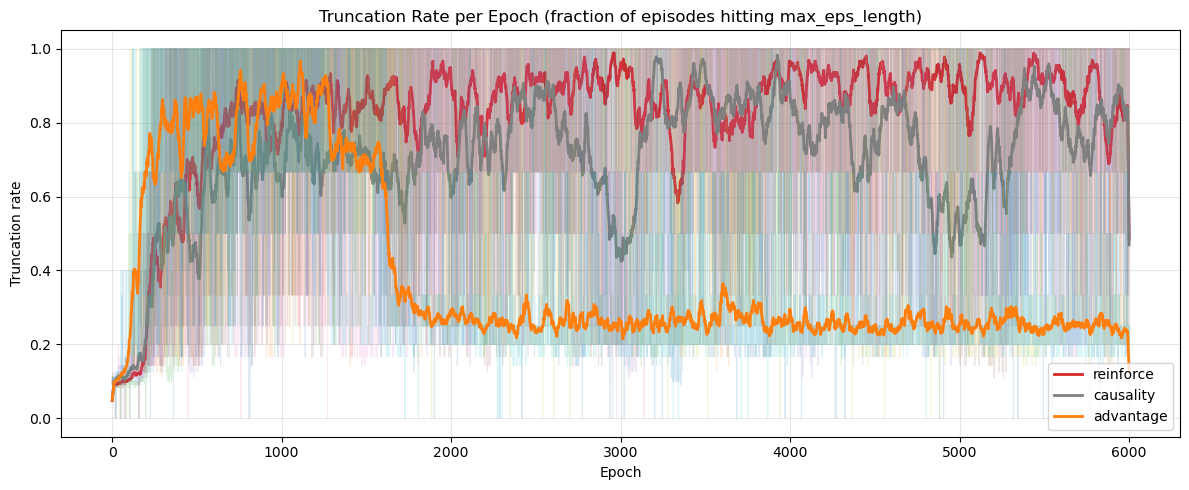

In [17]:

# Plot truncation rate per epoch for each method: the fraction of episodes
# that hit max_eps_length before resolving (landing or crashing), rather than
# ending via terminated/truncated from the env. A high or persistent
# truncation rate indicates the policy is stalling/hovering instead of
# completing landings -- see training notes above for the investigation this
# diagnostic was built to support. With multiple seeds per method, each
# seed's curve is drawn faintly and the across-seed mean is bolded.
#
# Only runs when `comparison_results` exists (i.e. after running
# `compare_methods()` in the cell above) -- skipped while that cell is
# instead running a `sweep_time_penalty()` call, which prints its own
# summary table directly.
if 'comparison_results' in dir():
    fig, ax = plt.subplots(figsize=(12, 5))
    for method, result in comparison_results.items():
        all_rates = [trainer.epoch_truncation_rates for trainer in result['trainers']]
        for rates in all_rates:
            xs = np.arange(1, len(rates) + 1)
            ax.plot(xs, rates, alpha=0.15, linewidth=0.8)
        min_len = min(len(r) for r in all_rates)
        mean_rates = np.mean([r[:min_len] for r in all_rates], axis=0)
        xs = np.arange(1, min_len + 1)
        ax.plot(xs, _smooth(mean_rates), linewidth=2, label=method)

    ax.set_title('Truncation Rate per Epoch (fraction of episodes hitting max_eps_length)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Truncation rate')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Skipped: comparison_results not defined (cell above ran a time_penalty sweep instead).")

In [18]:

# LunarLander-v3 passing test: report an aggregate pass/fail per method using
# the eval_returns already computed by compare_methods() (no need to re-run
# eval_n_episodes here now that compare_methods does it during training).
# With multiple seeds, "passing" is judged on the across-seed mean rather
# than any single seed's draw, since individual seeds have shown swings
# large enough to flip pass/fail on their own.
#
# Only runs when `comparison_results` exists (from `compare_methods()`).
PASSING_SCORE = 200

if 'comparison_results' in dir():
    print(f"LunarLander-v3 passing test  (threshold = {PASSING_SCORE})\n")
    print(f"{'Method':<12} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}  {'Pass?':>6}   Per-seed means")
    print("-" * 100)

    for method, result in comparison_results.items():
        per_seed_returns = result['eval_returns']
        per_seed_means = [float(np.mean(r)) for r in per_seed_returns]
        all_returns = [r for seed_returns in per_seed_returns for r in seed_returns]
        mean_r = np.mean(all_returns)
        passed = mean_r >= PASSING_SCORE
        seed_means_str = ', '.join(f'{m:.1f}' for m in per_seed_means)
        print(
            f"{method:<12} {mean_r:>8.1f} {np.std(all_returns):>8.1f}"
            f" {np.min(all_returns):>8.1f} {np.max(all_returns):>8.1f}  {'PASS' if passed else 'FAIL':>6}"
            f"   [{seed_means_str}]"
        )
else:
    print("Skipped: comparison_results not defined (cell above ran a time_penalty sweep instead;"
          " see its printed table for results).")

LunarLander-v3 passing test  (threshold = 200)

Method           Mean      Std      Min      Max   Pass?   Per-seed means
----------------------------------------------------------------------------------------------------
reinforce       123.2     54.3    -87.1    272.7    FAIL   [125.6, 128.0, 116.2]
causality       137.2     81.4    -38.5    313.6    FAIL   [159.7, 123.4, 128.7]
advantage       244.6     82.5    -26.5    322.9    PASS   [254.8, 237.7, 241.4]
